In [22]:
#!git clone https://github.com/med2106/dsan6600_group04_project.git

In [23]:
#%cd dsan6600_group04_project

In [24]:
#!unzip data/segmented.zip -d data/

In [25]:
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

In [26]:
# Check GPU availability
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Available: {gpu_name}")
    print(f"Memory: {gpu_memory:.1f} GB")
else:
    raise RuntimeError("GPU required for training")


GPU Available: NVIDIA A100-SXM4-80GB
Memory: 85.2 GB


In [27]:
import os
import time
import shutil
import torch
from torch import nn
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from torchvision import transforms, datasets
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.notebook import tqdm

SOURCE_DATA_DIR = "data/segmented"  # Source data with class folders
OUTPUT_DIR = "data/train_val_split"  # Where train/val split will be saved

IMG_SIZE = 600
INITIAL_BATCH_SIZE = 8  # A100 High-RAM can handle larger batches
ACCUMULATION_STEPS = 2  # Reduced since we can use larger batches (8*2=16 effective)
EPOCHS = 20
LR = 3e-4
CHECKPOINT_DIR = "data/checkpoints/efficientnet_b7/"

# Train/val split ratios
TRAIN_RATIO = 0.8
VAL_RATIO = 0.2

# Memory optimization: Freeze backbone initially (optional)
# Set to True to freeze feature extractor initially
FREEZE_BACKBONE = False

# Early stopping: Stop training if validation accuracy doesn't improve for N epochs
# Set to 0 to disable early stopping
EARLY_STOPPING_PATIENCE = 5  # Stop if no improvement for 5 epochs

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [28]:
def split_dataset(source_dir, output_dir, train_ratio=0.8, val_ratio=0.2):
    """Split images from class folders into train/val structure.

    This creates new folders at output_dir/train/ and output_dir/val/
    """
    assert abs(train_ratio + val_ratio - 1.0) < 1e-5, "Ratios must sum to 1"

    # Check if output directory already exists and warn
    train_path = os.path.join(output_dir, "train")
    val_path = os.path.join(output_dir, "val")

    if os.path.exists(train_path) or os.path.exists(val_path):
        print(f" WARNING: Output directory {output_dir} already contains train/val folders.")


    # Create output directories (delete existing if present)
    for split in ['train', 'val']:
        split_path = os.path.join(output_dir, split)
        if os.path.exists(split_path):
            shutil.rmtree(split_path)
            print(f"   Deleted existing {split_path}")
        os.makedirs(split_path)
        print(f"   Created {split_path}")

    # Get class folders
    classes = [d for d in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, d))]
    classes.sort()
    print(f"Found {len(classes)} classes: {classes}")

    stats = defaultdict(lambda: defaultdict(int))

    for cls in classes:
        cls_path = os.path.join(source_dir, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        if len(images) < 2:
            print(f" Warning: Class '{cls}' has only {len(images)} images, skipping")
            continue

        # Split into train and val
        train_imgs, val_imgs = train_test_split(
            images, train_size=train_ratio, random_state=42, shuffle=True
        )

        # Copy images to respective folders
        for split, img_list in [('train', train_imgs), ('val', val_imgs)]:
            split_cls_path = os.path.join(output_dir, split, cls)
            os.makedirs(split_cls_path, exist_ok=True)
            for img in img_list:
                src = os.path.join(cls_path, img)
                dst = os.path.join(split_cls_path, img)
                shutil.copy2(src, dst)
            stats[cls][split] = len(img_list)

    # Print statistics
    print("\n" + "="*50)
    print("Dataset Split Statistics")
    print("="*50)
    print(f"{'Class':<10} {'Train':<10} {'Val':<10} {'Total':<10}")
    print("-" * 50)
    total_train, total_val = 0, 0
    for cls in classes:
        if cls in stats:
            total = stats[cls]['train'] + stats[cls]['val']
            total_train += stats[cls]['train']
            total_val += stats[cls]['val']
            print(f"{cls:<10} {stats[cls]['train']:<10} {stats[cls]['val']:<10} {total:<10}")
    print("-" * 50)
    print(f"{'TOTAL':<10} {total_train:<10} {total_val:<10} {total_train+total_val:<10}")

    return classes

# Verify source data exists
if not os.path.exists(SOURCE_DATA_DIR):
    print(f" Source data directory not found: {SOURCE_DATA_DIR}")
    raise FileNotFoundError(f"Source data directory not found: {SOURCE_DATA_DIR}")

# Run the split
CLASS_NAMES = split_dataset(SOURCE_DATA_DIR, OUTPUT_DIR, TRAIN_RATIO, VAL_RATIO)


   Deleted existing data/train_val_split/train
   Created data/train_val_split/train
   Deleted existing data/train_val_split/val
   Created data/train_val_split/val
Found 10 classes: ['1', '2a', '2b', '2c', '3a', '3b', '3c', '4a', '4b', '4c']

Dataset Split Statistics
Class      Train      Val        Total     
--------------------------------------------------
1          1163       291        1454      
2a         1161       291        1452      
2b         978        245        1223      
2c         967        242        1209      
3a         955        239        1194      
3b         1004       251        1255      
3c         959        240        1199      
4a         935        234        1169      
4b         1269       318        1587      
4c         1547       387        1934      
--------------------------------------------------
TOTAL      10938      2738       13676     


In [29]:
# Data augmentation for training
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # Slightly larger for random crop
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),  # Increased rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Small translations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1)  # Random erasing for regularization
])

# Validation transforms (no augmentation)
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Create datasets from split data
train_path = os.path.join(OUTPUT_DIR, "train")
val_path = os.path.join(OUTPUT_DIR, "val")

train_ds = datasets.ImageFolder(train_path, train_tfms)
val_ds = datasets.ImageFolder(val_path, val_tfms)
num_classes = len(train_ds.classes)

print(f"\n Detected {num_classes} classes: {train_ds.classes}")
print(f"   Training samples: {len(train_ds)}")
print(f"   Validation samples: {len(val_ds)}")



 Detected 10 classes: ['1', '2a', '2b', '2c', '3a', '3b', '3c', '4a', '4b', '4c']
   Training samples: 10938
   Validation samples: 2738


In [30]:
# Load pretrained EfficientNet-B7
print("Loading EfficientNet-B7 with ImageNet weights...")
weights = EfficientNet_B7_Weights.IMAGENET1K_V1
model = efficientnet_b7(weights=weights)

# Replace classifier for hair type classification
classifier = model.classifier
in_features = classifier[1].in_features
classifier[0] = nn.Dropout(p=0.5, inplace=True)
classifier[1] = nn.Linear(in_features, num_classes)
model.classifier = classifier

model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n Model loaded successfully")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# Optionally freeze backbone to save memory and speed up training
if FREEZE_BACKBONE:
    print(" Freezing backbone (feature extractor) to save memory...")
    for param in model.features.parameters():
        param.requires_grad = False
    print("   Only classifier will be trained initially")
    print("   (You can unfreeze later by setting FREEZE_BACKBONE = False)")

# Loss, optimizer, scaler
# Using label smoothing for better generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4, betas=(0.9, 0.999))
scaler = GradScaler('cuda')  # Updated API for PyTorch 2.0+

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)
print(" Learning rate scheduler: ReduceLROnPlateau (reduces LR when val loss plateaus)")

# Enable gradient checkpointing to save memory (PyTorch 2.0+)
try:
    if hasattr(torch.utils.checkpoint, 'checkpoint'):
        # This will use less memory during forward pass
        print(" Gradient checkpointing available (saves memory)")
except:
    pass


Loading EfficientNet-B7 with ImageNet weights...

 Model loaded successfully
   Total parameters: 63,812,570
   Trainable parameters: 63,812,570
 Learning rate scheduler: ReduceLROnPlateau (reduces LR when val loss plateaus)
 Gradient checkpointing available (saves memory)


In [31]:
def find_largest_batch_size(initial_bs=INITIAL_BATCH_SIZE):
    """Automatically find the largest batch size that fits in GPU memory."""
    bs = initial_bs
    while bs > 0:
        try:
            test_loader = torch.utils.data.DataLoader(
                train_ds,
                batch_size=bs,
                shuffle=True,
                num_workers=4,  # A100 can handle more workers
                pin_memory=True
            )
            images, labels = next(iter(test_loader))
            images = images.to(device)
            labels = labels.to(device)
            # Try a forward pass with the model
            with autocast('cuda'):
                _ = model(images)
            print(f" Batch size {bs} fits in memory.")
            return bs
        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f" Batch size {bs} OOM → trying smaller batch...")
                torch.cuda.empty_cache()
                bs //= 2
            else:
                raise e
    raise RuntimeError("Could not find any valid batch size.")

BATCH_SIZE = find_largest_batch_size()
print(f" Using batch size: {BATCH_SIZE}\n")

# Create data loaders with optimal batch size
# Using num_workers=0 and pin_memory=False to save memory
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=False)  # Optimized for memory
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False)  # Optimized for memory

print(f" Data loaders created")
print(f"   Effective batch size: {BATCH_SIZE * ACCUMULATION_STEPS}")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")


 Batch size 8 fits in memory.
 Using batch size: 8

 Data loaders created
   Effective batch size: 16
   Image size: 600x600


In [32]:
# Check if we have a saved checkpoint to resume from
checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")

start_epoch = 1
resume_training = False
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

# Set this to True to resume from checkpoint, False to start fresh
RESUME_TRAINING = True  # Change to False if you want to start from scratch

if RESUME_TRAINING and os.path.exists(checkpoint_path):
    print(f"Found checkpoint: {checkpoint_path}")
    print("   Loading checkpoint to resume training...")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    history = checkpoint['history']
    patience_counter = checkpoint.get('patience_counter', 0)  # Restore patience counter

    print(f"   Resumed from epoch {checkpoint['epoch']}")
    print(f"   Previous best accuracy: {best_val_acc:.4f}")
    print(f"   Patience counter: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
    print(f"   Continuing from epoch {start_epoch} to {EPOCHS}")
    resume_training = True
elif RESUME_TRAINING and os.path.exists(best_model_path):
    print(f"Found best_model.pth but no latest_checkpoint.pth")
    print(f"   Loading best model weights (will start from epoch 1)")
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"   Set RESUME_TRAINING = False to start completely fresh")
else:
    if RESUME_TRAINING:
        print("No checkpoint found. Starting fresh training.")
    else:
        print("Starting fresh training (RESUME_TRAINING = False)")


No checkpoint found. Starting fresh training.


In [33]:
def validate(return_predictions=False):
    """Validate the model on validation set."""
    model.eval()
    total, correct = 0, 0
    running_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validating", leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            with autocast('cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += len(labels)

            # Update progress bar
            current_acc = correct / total if total > 0 else 0
            pbar.set_postfix({'acc': f'{current_acc:.4f}'})

            if return_predictions:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    avg_loss = running_loss / len(val_loader)

    if return_predictions:
        f1 = f1_score(all_labels, all_preds, average='weighted')
        return avg_loss, accuracy, f1, all_preds, all_labels
    else:
        return avg_loss, accuracy


In [34]:
print(f"\n{'='*60}")
if resume_training:
    print(f"Resuming Training (Epoch {start_epoch} to {EPOCHS})")
else:
    print("Starting Training")
print(f"{'='*60}")
print(f"Epochs: {start_epoch} to {EPOCHS}")
print(f"Batch size: {BATCH_SIZE} (effective: {BATCH_SIZE * ACCUMULATION_STEPS})")
print(f"Learning rate: {LR}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
if EARLY_STOPPING_PATIENCE > 0:
    print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE} epochs")
print(f"{'='*60}\n")

# Initialize early stopping counter (restore from checkpoint if resuming)
if not resume_training:
    patience_counter = 0

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    running_loss = 0
    start = time.time()

    optimizer.zero_grad()

    # Training loop with progress bar
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]",
                leave=True, ncols=100)

    for i, (imgs, labels) in enumerate(pbar):
        imgs, labels = imgs.to(device), labels.to(device)

        with autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            # A100 has plenty of memory, so we don't need frequent cache clearing
            # Only clear cache every 50 accumulation steps to prevent gradual memory leak
            if (i + 1) % (ACCUMULATION_STEPS * 50) == 0:
                torch.cuda.empty_cache()

        running_loss += loss.item() * ACCUMULATION_STEPS

        # Update progress bar with current loss
        current_loss = running_loss / (i + 1)
        pbar.set_postfix({'loss': f'{current_loss:.4f}'})

    train_loss = running_loss / len(train_loader)
    val_loss, val_acc = validate()
    duration = time.time() - start

    # Update learning rate scheduler based on validation loss
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Print message if learning rate was reduced
    if current_lr < old_lr:
        print(f" Learning rate reduced: {old_lr:.2e} → {current_lr:.2e}")

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.2e} | Time: {duration:.1f}s")

    # Save best model and reset patience counter
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        ckpt_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
        torch.save(model.state_dict(), ckpt_path)
        print(f"  New best model saved! (acc: {best_val_acc:.4f})")
        patience_counter = 0  # Reset patience when we see improvement
    else:
        # No improvement this epoch
        if EARLY_STOPPING_PATIENCE > 0:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{EARLY_STOPPING_PATIENCE} patience)")

    # Early stopping check
    if EARLY_STOPPING_PATIENCE > 0 and patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n{'='*60}")
        print(f"Early stopping triggered!")
        print(f"No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        print(f"Best validation accuracy: {best_val_acc:.4f}")
        print(f"Stopped at epoch {epoch}")
        print(f"{'='*60}\n")
        break

    # Save checkpoint after each epoch (for resume capability)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),  # Save scheduler state
        'best_val_acc': best_val_acc,
        'history': history,
        'patience_counter': patience_counter,  # Save patience counter
    }
    latest_ckpt_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
    torch.save(checkpoint, latest_ckpt_path)
    print(f"  Checkpoint saved (epoch {epoch})")

print(f"\n{'='*60}")
if EARLY_STOPPING_PATIENCE > 0 and patience_counter >= EARLY_STOPPING_PATIENCE:
    print(f"Training stopped early (no improvement for {EARLY_STOPPING_PATIENCE} epochs)")
else:
    print(f"Training Complete!")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Total epochs trained: {len(history['train_loss'])}")
print(f"{'='*60}")



Starting Training
Epochs: 1 to 20
Batch size: 8 (effective: 16)
Learning rate: 0.0003
Image size: 600x600
Early stopping patience: 5 epochs



Epoch 01/20 [Train]:   0%|                                                 | 0/1368 [00:00<?, ?it/s]

Validating:   0%|          | 0/343 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.7016 | Val Loss: 1.5204 | Val Acc: 0.4858 | LR: 3.00e-04 | Time: 763.8s
  New best model saved! (acc: 0.4858)
  Checkpoint saved (epoch 1)


Epoch 02/20 [Train]:   0%|                                                 | 0/1368 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/343 [00:00<?, ?it/s]

Epoch 14/20 | Train Loss: 0.9262 | Val Loss: 1.5890 | Val Acc: 0.5161 | LR: 1.50e-04 | Time: 727.1s
  No improvement (4/5 patience)
  Checkpoint saved (epoch 14)


Epoch 15/20 [Train]:   0%|                                                 | 0/1368 [00:00<?, ?it/s]

Validating:   0%|          | 0/343 [00:00<?, ?it/s]

 Learning rate reduced: 1.50e-04 → 7.50e-05
Epoch 15/20 | Train Loss: 0.8983 | Val Loss: 1.6325 | Val Acc: 0.5296 | LR: 7.50e-05 | Time: 733.1s
  No improvement (5/5 patience)

Early stopping triggered!
No improvement for 5 epochs.
Best validation accuracy: 0.5325
Stopped at epoch 15


Training stopped early (no improvement for 5 epochs)
Best validation accuracy: 0.5325
Total epochs trained: 15


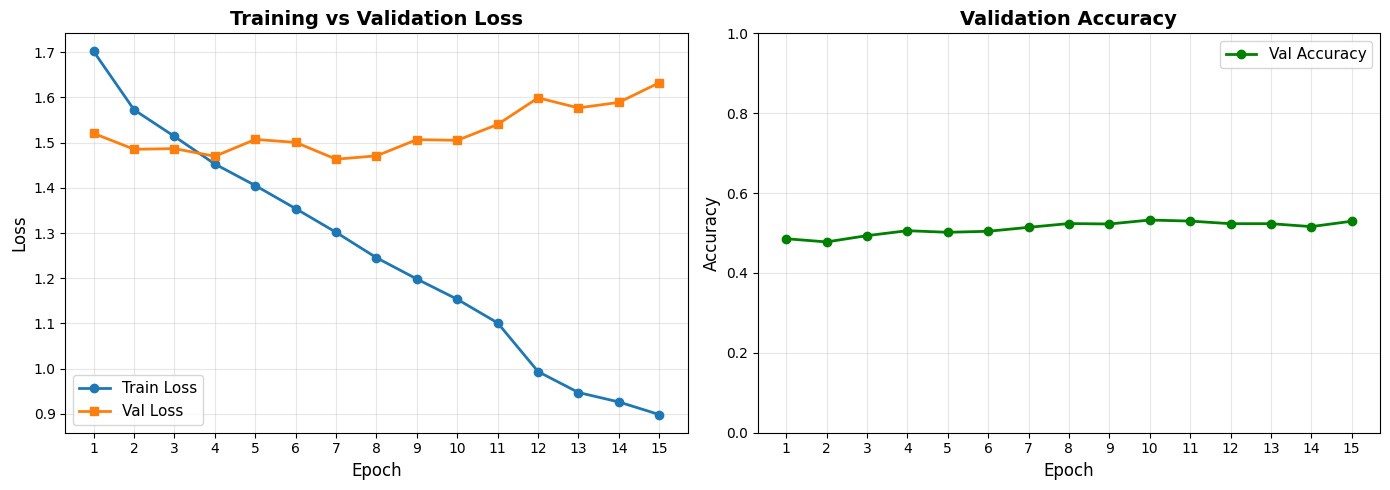

In [35]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

# Accuracy plot
axes[1].plot(epochs_range, history['val_acc'], label='Val Accuracy', color='green', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_history_v7.png'), dpi=150, bbox_inches='tight')
plt.show()



Loaded best model from data/checkpoints/efficientnet_b7/best_model.pth

=== Evaluating on Validation Set ===


Validating:   0%|          | 0/343 [00:00<?, ?it/s]


Validation Results
Validation Loss:     1.5051
Validation Accuracy: 0.5325 (53.25%)
Validation F1 Score: 0.5115

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.85      0.90      0.87       291
          2a       0.71      0.70      0.70       291
          2b       0.66      0.65      0.66       245
          2c       0.58      0.57      0.57       242
          3a       0.48      0.38      0.43       239
          3b       0.41      0.35      0.38       251
          3c       0.44      0.54      0.48       240
          4a       0.38      0.29      0.33       234
          4b       0.20      0.08      0.11       318
          4c       0.44      0.76      0.56       387

    accuracy                           0.53      2738
   macro avg       0.52      0.52      0.51      2738
weighted avg       0.51      0.53      0.51      2738



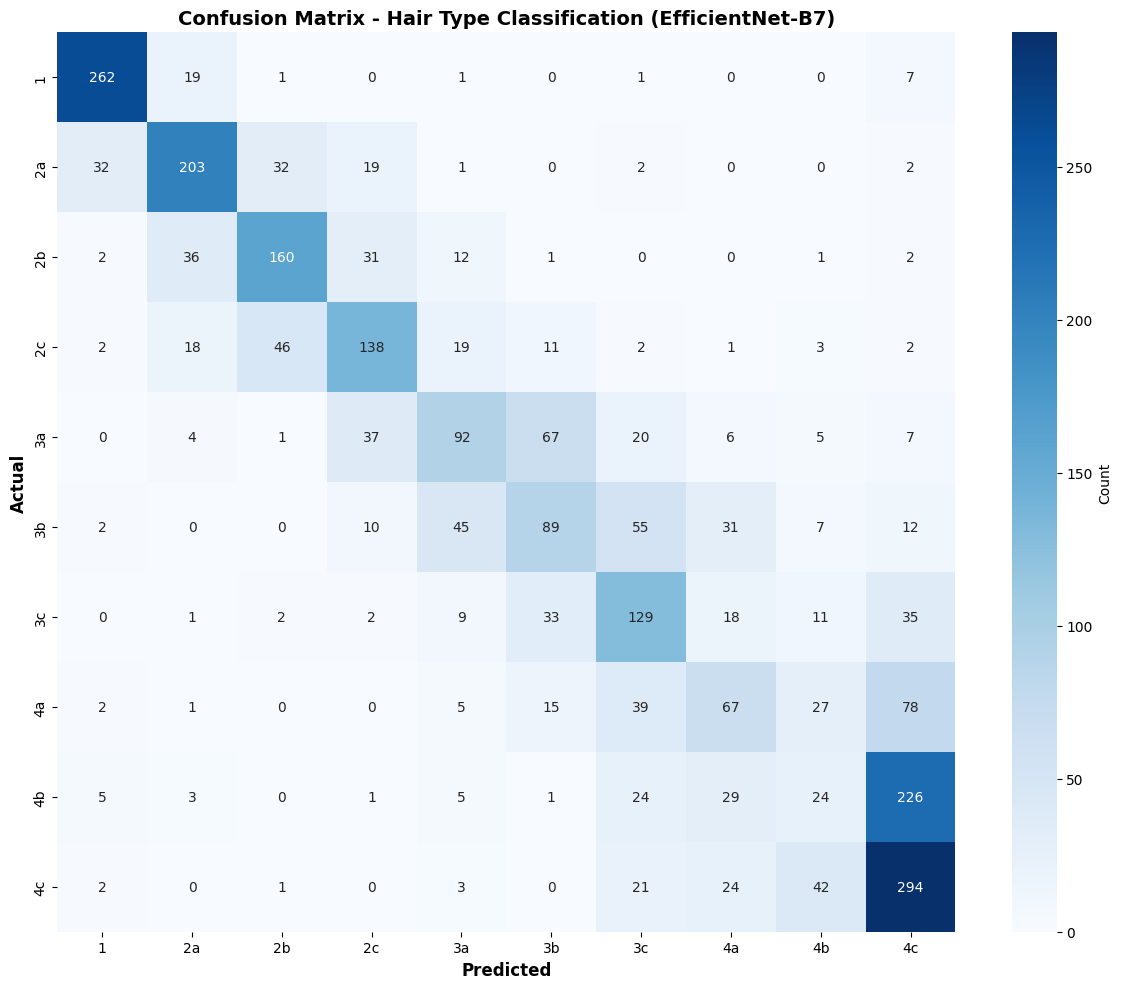

In [36]:
# Load best model for evaluation
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Loaded best model from {best_model_path}")
else:
    print("Using current model (no best_model.pth found)")

# Evaluate on validation set with predictions
print("\n=== Evaluating on Validation Set ===")
val_loss, val_acc, val_f1, val_preds, val_labels = validate(return_predictions=True)

print(f"\n{'='*50}")
print("Validation Results")
print(f"{'='*50}")
print(f"Validation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Validation F1 Score: {val_f1:.4f}")
print(f"{'='*50}")

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(val_labels, val_preds, target_names=train_ds.classes))

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Hair Type Classification (EfficientNet-B7)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'confusion_matrix_v7.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
def save_model_for_deployment(model, save_path, num_classes, class_names, img_size):
    """Save model in format compatible with Streamlit app."""
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'num_classes': num_classes,
        'class_names': list(class_names),
        'img_size': img_size,
        'model_architecture': 'efficientnet_b7'
    }
    torch.save(checkpoint, save_path)
    print(f"Saved deployment model → {save_path}")

# Save the model in the exact format the Streamlit app expects
final_model_path = os.path.join(CHECKPOINT_DIR, "efficientnet_b7_hair_classifier.pth")
save_model_for_deployment(
    model=model,
    save_path=final_model_path,
    num_classes=num_classes,
    class_names=train_ds.classes,
    img_size=IMG_SIZE
)

print(f"\nModel files saved in: {CHECKPOINT_DIR}")
print("Download 'efficientnet_b7_hair_classifier.pth' for your Streamlit app!")


In [38]:
from google.colab import files
files.download('data/checkpoints/efficientnet_b7/efficientnet_b7_hair_classifier.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>